<a href="https://colab.research.google.com/github/iNuman/PytorchDeepLearnignPlayGround/blob/main/LinearRegModelClass.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<Axes: xlabel='wt', ylabel='mpg'>

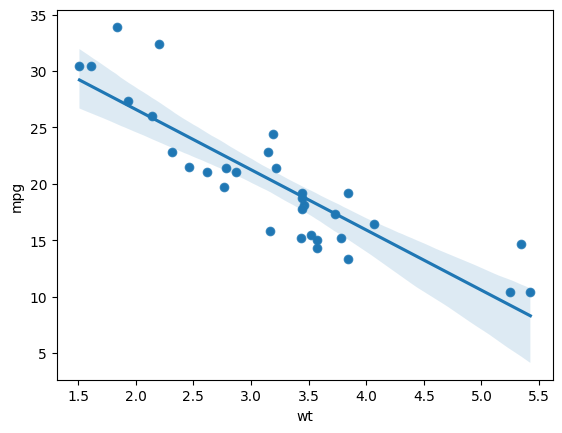

In [23]:
#%% packages
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import seaborn as sns

#%% data import
cars_file = 'https://gist.githubusercontent.com/noamross/e5d3e859aa0c794be10b/raw/b999fb4425b54c63cab088c0ce2c0d6ce961a563/cars.csv'
cars = pd.read_csv(cars_file)
cars.head()

#%% visualise the model
sns.scatterplot(x='wt', y='mpg', data=cars)
sns.regplot(x='wt', y='mpg', data=cars)



Epoch 0, Loss: 332.2528381347656
Epoch 100, Loss: 84.50257110595703
Epoch 200, Loss: 64.61639404296875
Epoch 300, Loss: 49.94700622558594
Epoch 400, Loss: 39.12588882446289
Epoch 500, Loss: 31.143524169921875
Epoch 600, Loss: 25.255199432373047
Epoch 700, Loss: 20.911577224731445
Epoch 800, Loss: 17.70743179321289
Epoch 900, Loss: 15.343840599060059
Epoch 1000, Loss: 13.600302696228027
Epoch 1100, Loss: 12.314144134521484
Epoch 1200, Loss: 11.365399360656738
Epoch 1300, Loss: 10.665533065795898
Epoch 1400, Loss: 10.14926528930664
Epoch 1500, Loss: 9.768430709838867
Epoch 1600, Loss: 9.487512588500977
Epoch 1700, Loss: 9.280280113220215
Epoch 1800, Loss: 9.12741756439209
Epoch 1900, Loss: 9.014652252197266
Epoch 2000, Loss: 8.931472778320312
Epoch 2100, Loss: 8.870104789733887
Epoch 2200, Loss: 8.824840545654297
Epoch 2300, Loss: 8.791448593139648
Epoch 2400, Loss: 8.766818046569824
Epoch 2500, Loss: 8.748650550842285
Epoch 2600, Loss: 8.735247611999512
Epoch 2700, Loss: 8.7253627777099

<Axes: >

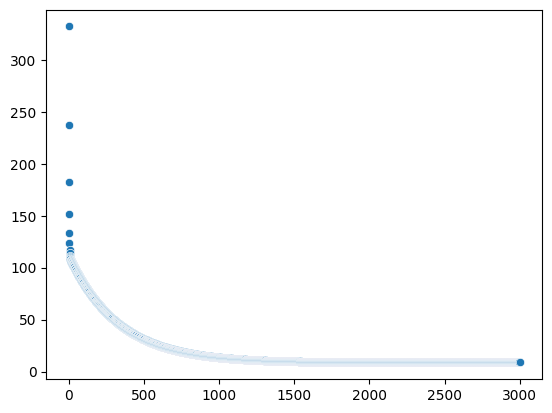

In [24]:
#%% convert data to tensor
X_list = cars.wt.values
X_np = np.array(X_list, dtype=np.float32).reshape(-1,1)
y_list = cars.mpg.values
y_np = np.array(y_list, dtype=np.float32).reshape(-1,1)
X = torch.from_numpy(X_np)
y_true = torch.from_numpy(y_np)

#%%
class LinearRegressionTorch(nn.Module):
    def __init__(self, input_size, output_size):
        super(LinearRegressionTorch, self).__init__()
        self.linear = nn.Linear(input_size, output_size)

    def forward(self, x):
        return self.linear(x)

input_dim = 1
output_dim = 1
model = LinearRegressionTorch(input_size=input_dim, output_size=output_dim)


# %% Mean Squared Error
loss_fun = nn.MSELoss()

#%% Optimizer
LR = 0.01
# test different values of too large 0.1 and too small 0.001
# best 0.02
optimizer = torch.optim.SGD(model.parameters(), lr=LR)

#%% perform training
losses, slope, bias = [], [], []
NUM_EPOCHS = 3000
for epoch in range(NUM_EPOCHS):

    # set gradients to zero
    optimizer.zero_grad()

    # forward pass
    y_pred = model(X)

    # calculate loss
    loss = loss_fun(y_pred, y_true)
    loss.backward()

    # update parameters
    optimizer.step()

    # get parameters
    for name, param in model.named_parameters():
        if param.requires_grad:
            if name == 'linear.weight':
                slope.append(param.data.numpy()[0][0])
            if name == 'linear.bias':
                bias.append(param.data.numpy()[0])


    # store loss
    losses.append(float(loss.data))
    # print loss
    if (epoch % 100 == 0):
        print(f"Epoch {epoch}, Loss: {loss.data}")

# %% visualise model training
sns.scatterplot(x=range(NUM_EPOCHS), y=losses)

<Axes: >

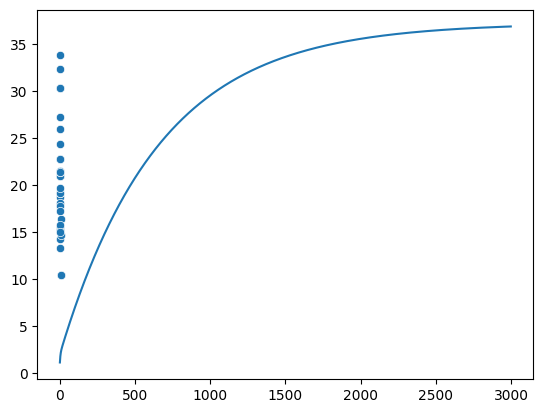

In [25]:
#%% visualise the bias development
sns.lineplot(x=range(NUM_EPOCHS), y=bias)
sns.scatterplot(x=X_list, y=y_list)


<Axes: >

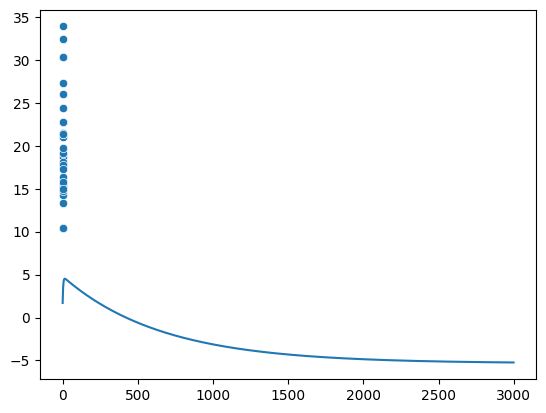

In [26]:
#%% visualise the slope development
sns.lineplot(x=range(NUM_EPOCHS), y=slope)
sns.scatterplot(x=X_list, y=y_list)


<Axes: >

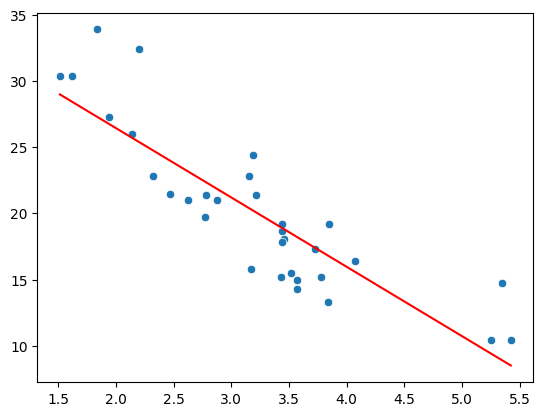

In [27]:

# %% check the result
y_pred = model(X).data.numpy().reshape(-1)
sns.scatterplot(x=X_list, y=y_list)
sns.lineplot(x=X_list, y=y_pred, color='red')